In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

In [113]:
df = pd.read_csv("heart_disease.csv")
print(df.head())

   Age  Gender Blood Pressure Cholesterol Glucose Smoking Alcohol Consumption  \
0   69    Male           High        High    High     Yes                  No   
1   32    Male            Low        High  Normal     Yes                  No   
2   89  Female         Normal        High  Normal      No                  No   
3   78    Male           High        High    High      No                  No   
4   38    Male            Low      Normal  Normal     Yes                 Yes   

  Exercise        BMI Family History  Heart Disease  
0       No  35.671099             No              1  
1      Yes  38.554188            Yes              0  
2      Yes  18.932964            Yes              1  
3      Yes  21.806350            Yes              0  
4      Yes  37.552683             No              0  


In [114]:
df

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0
...,...,...,...,...,...,...,...,...,...,...,...
995,27,Female,Low,High,Normal,No,No,No,31.960176,Yes,1
996,51,Female,High,High,Normal,No,Yes,Yes,20.118492,Yes,0
997,72,Female,Normal,High,Normal,Yes,No,No,20.916536,Yes,0
998,49,Male,Normal,High,High,Yes,No,Yes,19.560143,Yes,0


In [115]:
df.shape

(1000, 11)

In [116]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   int64  
 1   Gender               1000 non-null   str    
 2   Blood Pressure       1000 non-null   str    
 3   Cholesterol          1000 non-null   str    
 4   Glucose              1000 non-null   str    
 5   Smoking              1000 non-null   str    
 6   Alcohol Consumption  1000 non-null   str    
 7   Exercise             1000 non-null   str    
 8   BMI                  1000 non-null   float64
 9   Family History       1000 non-null   str    
 10  Heart Disease        1000 non-null   int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 86.1 KB


In [117]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,52.881000,20.958915,18.000000,34.750000,52.500000,71.000000,89.000000
BMI,1000.0,29.213037,6.196368,18.504881,23.924004,28.892349,34.663806,39.974048
Heart Disease,1000.0,0.253000,0.434948,0.000000,0.000000,0.000000,1.000000,1.000000


In [118]:
df.columns.tolist()

['Age',
 'Gender',
 'Blood Pressure',
 'Cholesterol',
 'Glucose',
 'Smoking',
 'Alcohol Consumption',
 'Exercise',
 'BMI',
 'Family History',
 'Heart Disease']

In [119]:
df.isnull().sum()

Age                    0
Gender                 0
Blood Pressure         0
Cholesterol            0
Glucose                0
Smoking                0
Alcohol Consumption    0
Exercise               0
BMI                    0
Family History         0
Heart Disease          0
dtype: int64

In [120]:
numerical_cols=df.select_dtypes(include='number').drop(columns='Heart Disease').columns

In [121]:
numerical_cols

Index(['Age', 'BMI'], dtype='str')

In [122]:
type(numerical_cols)

pandas.Index

In [123]:
for col in numerical_cols:
    print(f"{col}: {df[col].duplicated().sum()} duplicate values")

Age: 928 duplicate values
BMI: 0 duplicate values


In [124]:
df.nunique()

Age                      72
Gender                    2
Blood Pressure            3
Cholesterol               2
Glucose                   2
Smoking                   2
Alcohol Consumption       2
Exercise                  2
BMI                    1000
Family History            2
Heart Disease             2
dtype: int64

In [125]:
Age = df['Age'].value_counts()

In [126]:
Age

Age
79    26
50    23
68    23
18    23
80    20
      ..
63     9
28     8
60     8
58     7
48     6
Name: count, Length: 72, dtype: int64

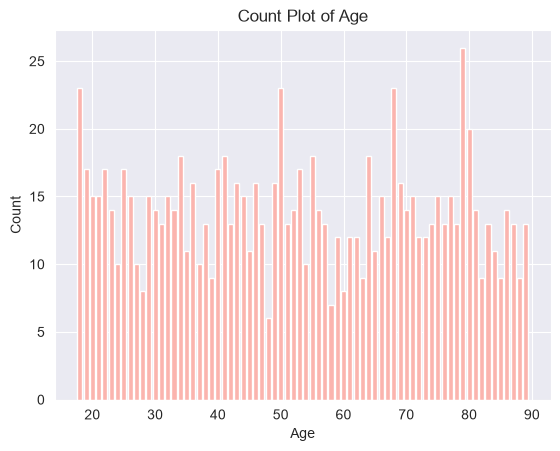

In [127]:
plt.bar(Age.index, Age)
plt.title('Count Plot of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

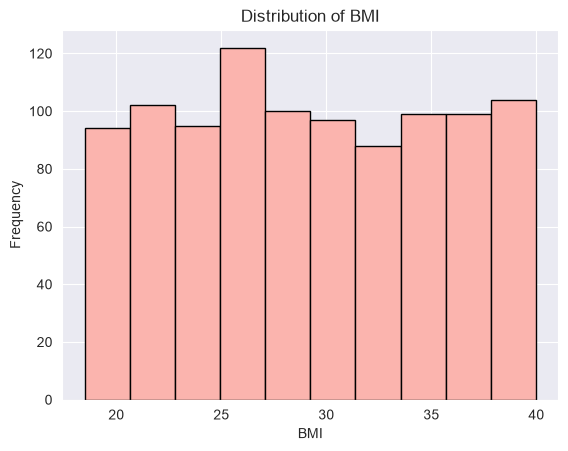

In [128]:
plt.hist(df['BMI'], bins=10,edgecolor='black')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

In [129]:
len(numerical_cols)

2

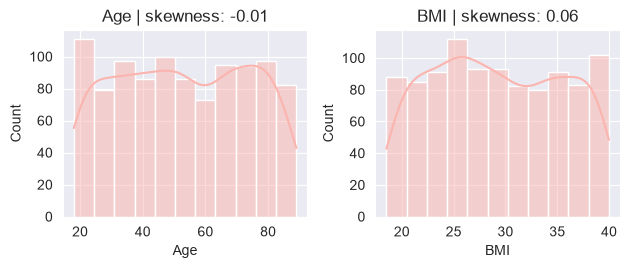

In [130]:
for idx, feature in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | skewness: {round(df[feature].skew(),2)}")
plt.tight_layout()
plt.show()

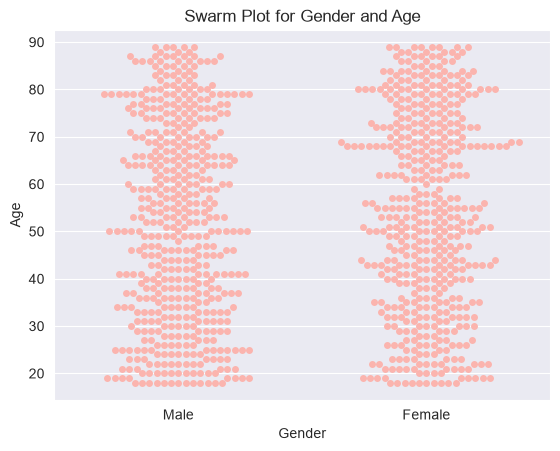

In [131]:
sns.swarmplot(x="Gender", y="Age", data=df)
plt.title('Swarm Plot for Gender and Age')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

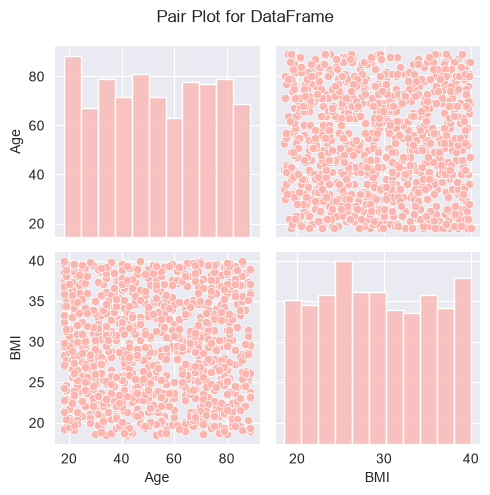

In [132]:
sns.pairplot(df[numerical_cols])
plt.suptitle('Pair Plot for DataFrame')
plt.tight_layout()
plt.show()

<Axes: xlabel='Age', ylabel='Gender'>

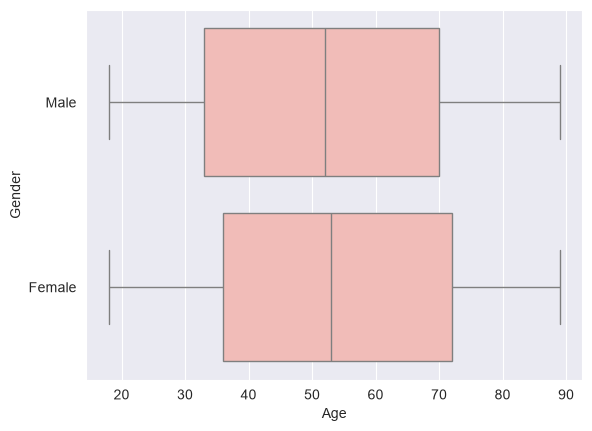

In [133]:
sns.boxplot(x='Age', y='Gender', data=df)

In [134]:
df_encoded = df.copy()
df_encoded['Gender'] = df_encoded['Gender'].map({
    'Male': 1,
    'Female': 0
})
df_encoded['Blood Pressure'] = df_encoded['Blood Pressure'].map({
    'Low': 0,
    'Normal': 1,
    'High': 2
})
df_encoded['Cholesterol'] = df_encoded['Cholesterol'].map({
    'Normal': 0,
    'High': 1
})
df_encoded['Glucose'] = df_encoded['Glucose'].map({
    'Normal': 0,
    'High': 1
})
df_encoded['Smoking'] = df_encoded['Smoking'].map({
    'No': 0,
    'Yes': 1
})
df_encoded['Alcohol Consumption'] = df_encoded['Alcohol Consumption'].map({
    'No': 0,
    'Yes': 1
})
df_encoded['Exercise'] = df_encoded['Exercise'].map({
    'No': 0,
    'Yes': 1
})
df_encoded['Family History'] = df_encoded['Family History'].map({
    'No': 0,
    'Yes': 1
})

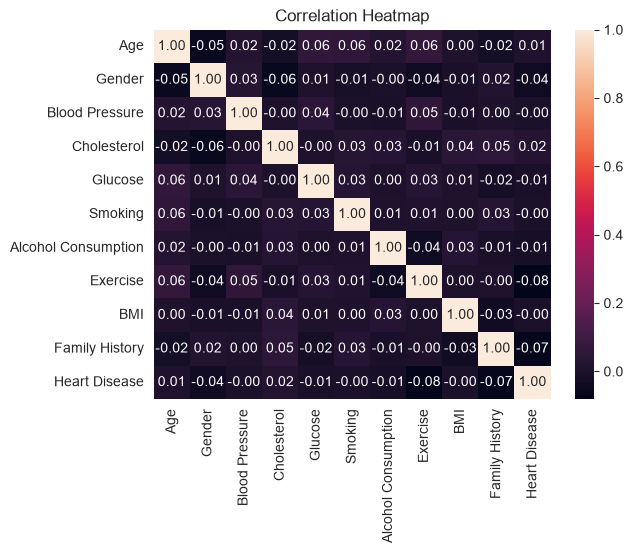

In [135]:
sns.heatmap(
    df_encoded.corr(),
    annot=True,
    fmt='.2f',
)
plt.title('Correlation Heatmap')
plt.show()

In [136]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

In [137]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans

In [142]:
df_encoded1=df.copy()

In [145]:
# 2. Automatically find ALL text columns, no matter what their hidden format is
text_columns = df_encoded1.select_dtypes(include=['object', 'category', 'string']).columns

# 3. Initialize and loop through only those text columns
le = LabelEncoder()
for col in text_columns:
    df_encoded1[col] = le.fit_transform(df_encoded1[col])

# 4. Print the result to confirm it worked!
print(df_encoded1.head())

   Age  Gender  Blood Pressure  Cholesterol  Glucose  Smoking  \
0   69       1               0            0        0        1   
1   32       1               1            0        1        1   
2   89       0               2            0        1        0   
3   78       1               0            0        0        0   
4   38       1               1            1        1        1   

   Alcohol Consumption  Exercise        BMI  Family History  Heart Disease  
0                    0         0  35.671099               0              1  
1                    0         1  38.554188               1              0  
2                    0         1  18.932964               1              1  
3                    0         1  21.806350               1              0  
4                    1         1  37.552683               0              0  


In [140]:


# Split data into Features (X) and Target (y)
# We drop 'Heart Disease' from X because we don't want the model to see the answers!
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

# 3. SPLIT DATA (Training set to learn, Testing set to grade the models)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data (makes it easier for models like Logistic Regression to read)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. THE MODEL SHOWDOWN
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

# Train and test each model
results = {}
for name, model in models.items():
    # Use scaled data for Logistic Regression, normal for trees (trees don't care about scaling)
    X_tr = X_train_scaled if name == "Logistic Regression" else X_train
    X_te = X_test_scaled if name == "Logistic Regression" else X_test
    
    # Train the model
    model.fit(X_tr, y_train)
    # Predict on unseen data
    predictions = model.predict(X_te)
    # Calculate accuracy score
    acc = accuracy_score(y_test, predictions)
    results[name] = acc

# 5. K-MEANS CLUSTERING (Unsupervised - Grouping people without looking at labels)
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_train_scaled) # Just groups them into 0 or 1 based on similarities

# 6. DISPLAY RESULTS
print("\n--- MODEL ACCURACY SHOWDOWN ---")
for model_name, score in results.items():
    print(f"{model_name}: {score * 100:.2f}% accurate")

ValueError: could not convert string to float: 'Female'